In [7]:
import pandas as pd

# RUTA DEL ARCHIVO XLSX
excel_file = pd.ExcelFile('DATA DE DIABETES 2025 - 2026.xlsx')

# Esto imprimirá la lista con los nombres de todas las pestañas
(excel_file.sheet_names)

['DICIEMBRE', 'NOVIEMBRE', 'OCTUBRE', 'SETIEMBRE', 'ENERO', 'FEBRERO']

In [2]:
#Descubrimiento como viene cada mes 
for mes in excel_file.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=mes)

    print(f"\n===== {mes} =====")

    if 'MES_RECEPCION' in df.columns:
        print(df['MES_RECEPCION'].value_counts(dropna=False).head(10))
    else:
        print("No existe la columna MES_RECEPCION")


===== DICIEMBRE =====
MES_RECEPCION
12    182422
Name: count, dtype: int64

===== NOVIEMBRE =====
No existe la columna MES_RECEPCION

===== OCTUBRE =====
No existe la columna MES_RECEPCION

===== SETIEMBRE =====
No existe la columna MES_RECEPCION

===== ENERO =====
MES_RECEPCION
1    150565
Name: count, dtype: int64

===== FEBRERO =====
MES_RECEPCION
2    439225
Name: count, dtype: int64


In [3]:
# Lista para almacenar los meses corregidos
lista_dataframes_limpios = []

for mes in excel_file.sheet_names:
    df_mes = pd.read_excel(excel_file, sheet_name=mes)

    if 'MES_RECEPCION' not in df_mes.columns:
        df_mes['MES_RECEPCION'] = mes

    if 'AÑO_RECEPCION' not in df_mes.columns:
        df_mes['AÑO_RECEPCION'] = 2025

    lista_dataframes_limpios.append(df_mes)

df_diabetes_consolidado = pd.concat(lista_dataframes_limpios, ignore_index=True)

In [8]:
# Unificar MES_RECEPCION a texto
mapa_meses = {1: 'ENERO', 2: 'FEBRERO', 3: 'MARZO', 4: 'ABRIL',
              5: 'MAYO', 6: 'JUNIO', 7: 'JULIO', 8: 'AGOSTO',
              9: 'SETIEMBRE', 10: 'OCTUBRE', 11: 'NOVIEMBRE', 12: 'DICIEMBRE',
              '1': 'ENERO', '2': 'FEBRERO', '3': 'MARZO', '4': 'ABRIL',
              '5': 'MAYO', '6': 'JUNIO', '7': 'JULIO', '8': 'AGOSTO',
              '9': 'SETIEMBRE', '10': 'OCTUBRE', '11': 'NOVIEMBRE', '12': 'DICIEMBRE'}

df_diabetes_consolidado['MES_RECEPCION'] = (
    df_diabetes_consolidado['MES_RECEPCION']
    .astype(str)
    .str.upper()
    .str.strip()
    .map(mapa_meses)
    .fillna(df_diabetes_consolidado['MES_RECEPCION'].astype(str).str.upper().str.strip())
)

In [9]:
print(df_diabetes_consolidado.shape)
print(df_diabetes_consolidado['MES_RECEPCION'].value_counts(dropna=False))

(2451565, 38)
MES_RECEPCION
OCTUBRE      624806
SETIEMBRE    557475
NOVIEMBRE    497072
FEBRERO      439225
DICIEMBRE    182422
ENERO        150565
Name: count, dtype: int64


In [10]:
lista_dataframes_limpios = []

for mes in excel_file.sheet_names:
    df_mes = pd.read_excel(excel_file, sheet_name=mes)

    # FORZAR consistencia del mes
    df_mes['MES_RECEPCION'] = mes

    # AÑO fijo si no existe
    if 'AÑO_RECEPCION' not in df_mes.columns:
        df_mes['AÑO_RECEPCION'] = 2025

    lista_dataframes_limpios.append(df_mes)

df_diabetes_consolidado = pd.concat(lista_dataframes_limpios, ignore_index=True)

In [11]:
df_diabetes_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451565 entries, 0 to 2451564
Data columns (total 38 columns):
 #   Column                                             Dtype  
---  ------                                             -----  
 0   CODIGO_IAFAS_CRIPTO                                object 
 1   CODIGO_IPRESS_CRIPTO                               object 
 2   TIPO_DOC_PAGO                                      int64  
 3   NUMERO_DOC_PAGO_CRIPTO                             object 
 4   CORRELATIVO_ATENCION                               int64  
 5   TIPO_AFILIACION_DEL_PACIENTE                       object 
 6   TIPO_DOC_IDENTIDAD                                 object 
 7   NUMERO_DOC_IDENTIDAD_CRIPTO                        object 
 8   TIPO_COBERTURA                                     object 
 9   SUBTIPO_COBERTURA                                  float64
 10  PRIMER_DIAGNOSTICO                                 object 
 11  TIPO_DIABETES                                     

In [12]:
# CONVERTIR FECHAS A DATETIME PARA LA CORRECION EN LAS FECHAS

df_diabetes_consolidado['FECHA_PRESTACION'] = pd.to_datetime(
    df_diabetes_consolidado['FECHA_PRESTACION'], 
    format='%Y%m%d',
    errors='coerce'
)

df_diabetes_consolidado['FECHA_NACIMIENTO_PACIENTE'] = pd.to_datetime(
    df_diabetes_consolidado['FECHA_NACIMIENTO_PACIENTE'], 
    format='%Y%m%d',
    errors='coerce'
)

In [13]:
#CORRECCIONES DE TIPOS 

df_diabetes_consolidado['SUBTIPO_COBERTURA'] = df_diabetes_consolidado['SUBTIPO_COBERTURA'].astype('Int64')

df_diabetes_consolidado['UBIGEO_IPRESS'] = df_diabetes_consolidado['UBIGEO_IPRESS'].astype('Int64')
    
df_diabetes_consolidado['UBIGEO_AFILIADO'] = df_diabetes_consolidado['UBIGEO_AFILIADO'].astype('Int64')

In [14]:
#CREACION DE LA NUEVA VARIABLE EDAD_PACIENTE
df_diabetes_consolidado['FECHA_PRESTACION'] = pd.to_datetime(
    df_diabetes_consolidado['FECHA_PRESTACION'],
    errors='coerce'
)

df_diabetes_consolidado['FECHA_NACIMIENTO_PACIENTE'] = pd.to_datetime(
    df_diabetes_consolidado['FECHA_NACIMIENTO_PACIENTE'],
    errors='coerce'
)

df_diabetes_consolidado['MES_PRESTACION'] = df_diabetes_consolidado['FECHA_PRESTACION'].dt.month
df_diabetes_consolidado['AÑO_PRESTACION'] = df_diabetes_consolidado['FECHA_PRESTACION'].dt.year

df_diabetes_consolidado['EDAD_PACIENTE'] = (
    (df_diabetes_consolidado['FECHA_PRESTACION'] - df_diabetes_consolidado['FECHA_NACIMIENTO_PACIENTE'])
    .dt.days // 365
)

In [15]:

print(df_diabetes_consolidado.dtypes)

CODIGO_IAFAS_CRIPTO                                          object
CODIGO_IPRESS_CRIPTO                                         object
TIPO_DOC_PAGO                                                 int64
NUMERO_DOC_PAGO_CRIPTO                                       object
CORRELATIVO_ATENCION                                          int64
TIPO_AFILIACION_DEL_PACIENTE                                 object
TIPO_DOC_IDENTIDAD                                           object
NUMERO_DOC_IDENTIDAD_CRIPTO                                  object
TIPO_COBERTURA                                               object
SUBTIPO_COBERTURA                                             Int64
PRIMER_DIAGNOSTICO                                           object
TIPO_DIABETES                                                object
FECHA_PRESTACION                                     datetime64[ns]
TIPO_PROFESIONAL                                             object
FECHA_NACIMIENTO_PACIENTE                       

In [16]:
df_diabetes_consolidado.head()

,CODIGO_IAFAS_CRIPTO,CODIGO_IPRESS_CRIPTO,TIPO_DOC_PAGO,NUMERO_DOC_PAGO_CRIPTO,CORRELATIVO_ATENCION,TIPO_AFILIACION_DEL_PACIENTE,TIPO_DOC_IDENTIDAD,NUMERO_DOC_IDENTIDAD_CRIPTO,TIPO_COBERTURA,SUBTIPO_COBERTURA,...,TOTAL_GASTOS_CUBIERTOS,TOTAL_LIQUIDADO_IAFAS,FECHA_RECEPCION_INFO,UBIGEO_AFILIADO,PERIODO_PUBLICACION,MES_RECEPCION,AÑO_RECEPCION,MES_PRESTACION,AÑO_PRESTACION,EDAD_PACIENTE
0,52C8E6961E279AA6459E8782F8F316B9220B782A,508E9DEDD8800D531EEA055C45B12CE9D3C0F444,1,17B7C2B1E44AA9267925495AECA5F50591FDC41E,1,REGULAR,DNI,835C9F2AF38C372063D979CDB461945DE489D670,MEDICINAS ALTERNATIVAS,989,...,4335.10,3468.08,2025-12-05 18:20:48,40101,122025,DICIEMBRE,2025,11,2025,55
1,F961052ED1A96844121655AF5EC3B2DCD21D0FA1,12373664293DC9290742A85CD6B6EDE0B30F6E41,1,6972C9DE52658E65855AD3877862E7D9ED974375,1,SCTR,DNI,9320641E84C3AB8BB0A031F3781C1812F6F1406E,MEDICINAS ALTERNATIVAS,100,...,337.40,398.13,2025-12-11 08:13:06,21309,122025,DICIEMBRE,2025,7,2025,56
2,52C8E6961E279AA6459E8782F8F316B9220B782A,E1C3A4472E5AF6008EBA2D590B8B5992AAAAD14C,1,1E1846BB48E233C7A7284CF0F329C01ED29D3661,1,REGULAR,DNI,3B3910F7D3486EDC1B6586DC17A3199663933E31,MEDICINAS ALTERNATIVAS,821,...,540.00,486.00,2025-12-05 17:21:59,140137,122025,DICIEMBRE,2025,11,2025,34
3,6573F717AD2F71A161CC9D104526A196DDC0C641,FA000B14669AFA164CA94DE1EF8D776F1539484F,1,404BA22B031B83947B17CCEE8D04CEFEA4E2A0C9,1,REGULAR,DNI,79429512177BACA5AF5CAB277282E752C894BAD1,MEDICINAS ALTERNATIVAS,100,...,439.44,138.66,2025-12-11 12:13:30,140115,122025,DICIEMBRE,2025,10,2025,68
4,EE11EB6B8BD1AD4912F94F2E3D055F4DE7ECC953,925608CF37F7206F1ADC0D88EE3E3964F9E0519C,1,A8970F4E5FF928B644FA062CC58DBA765E4FAD84,1,REGULAR,DNI,2DBE59BCEE90E02A857AEB381881CC36D448BF19,MEDICINAS ALTERNATIVAS,100,...,60.00,60.00,2025-12-12 16:33:22,40107,122025,DICIEMBRE,2025,9,2025,5


In [17]:
# Filtrar solo Diabetes (E10 y E11)
df_diabetes = df_diabetes_consolidado[
    df_diabetes_consolidado['PRIMER_DIAGNOSTICO']
    .astype(str)
    .str.contains(r'^E1[01]', case=False, na=False)
].copy()

print(df_diabetes.shape)

(60324, 41)


In [18]:
# Muestra el primer diagnóstico de diabetes tipo 1 o tipo 2
df_diabetes[['PRIMER_DIAGNOSTICO', 'TIPO_DIABETES']].head()

,PRIMER_DIAGNOSTICO,TIPO_DIABETES
11,E11.8,Tipo 2
26,E11.9,Tipo 2
47,E11.9,Tipo 2
83,E11.9,Tipo 2
196,E11.8,Tipo 2


In [19]:
# 1. Ver de qué años es la data que se leyó
print("--- Años detectados en la data ---")
print(df_diabetes['AÑO_RECEPCION'].value_counts())

print("\n--- Meses de recepción detectados ---")
# 2. Ver qué meses específicos se consolidaron 
print(df_diabetes['MES_RECEPCION'].value_counts())

print("\n--- Rango exacto de las atenciones médicas ---")
# 3. Ver la fecha de la primera y última atención registrada
print("Primera atención:", df_diabetes['FECHA_PRESTACION'].min())
print("Última atención:", df_diabetes['FECHA_PRESTACION'].max())

--- Años detectados en la data ---
AÑO_RECEPCION
2025    46876
2026    13448
Name: count, dtype: int64

--- Meses de recepción detectados ---
MES_RECEPCION
OCTUBRE      15547
SETIEMBRE    14371
NOVIEMBRE    12619
FEBRERO      10803
DICIEMBRE     4339
ENERO         2645
Name: count, dtype: int64

--- Rango exacto de las atenciones médicas ---
Primera atención: 2022-08-31 00:00:00
Última atención: 2026-01-23 00:00:00


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Variables numéricas
numeric_features = ["EDAD_PACIENTE", "TOTAL_GASTOS_CUBIERTOS", "TOTAL_LIQUIDADO_IAFAS",
    "GASTO_EN_FARMACIA", "GASTO_EXAMENES_LABORATORIO", "GASTO_EXAMENES_DE_IMAGENES",
    "GASTO_HONORARIOS_Y_PROCED"]

# Variables categóricas
categorical_features = ["TIPO_DIABETES", "TIPO_PROFESIONAL", "TIPO_AFILIACION_DEL_PACIENTE",
    "TIPO_COBERTURA", "SUBTIPO_COBERTURA", "PRIMER_DIAGNOSTICO", "FILIACION_PACIENTE",
    "SEXO_PACIENTE"]

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

In [21]:
#¿Están completos los datos? (Valores ausentes)
#Cantidad de nulos por columnas
df_diabetes.isnull().sum()

CODIGO_IAFAS_CRIPTO                                     0
CODIGO_IPRESS_CRIPTO                                    0
TIPO_DOC_PAGO                                           0
NUMERO_DOC_PAGO_CRIPTO                                  0
CORRELATIVO_ATENCION                                    0
TIPO_AFILIACION_DEL_PACIENTE                            0
TIPO_DOC_IDENTIDAD                                      0
NUMERO_DOC_IDENTIDAD_CRIPTO                             0
TIPO_COBERTURA                                          3
SUBTIPO_COBERTURA                                       0
PRIMER_DIAGNOSTICO                                      0
TIPO_DIABETES                                           0
FECHA_PRESTACION                                        0
TIPO_PROFESIONAL                                        0
FECHA_NACIMIENTO_PACIENTE                               0
SEXO_PACIENTE                                           0
FILIACION_PACIENTE                                      0
UBIGEO_IPRESS 

In [22]:
#Verificacion de los porcentaje de nulos
(df_diabetes.isnull().sum() / len(df_diabetes)) * 100

CODIGO_IAFAS_CRIPTO                                  0.000000
CODIGO_IPRESS_CRIPTO                                 0.000000
TIPO_DOC_PAGO                                        0.000000
NUMERO_DOC_PAGO_CRIPTO                               0.000000
CORRELATIVO_ATENCION                                 0.000000
TIPO_AFILIACION_DEL_PACIENTE                         0.000000
TIPO_DOC_IDENTIDAD                                   0.000000
NUMERO_DOC_IDENTIDAD_CRIPTO                          0.000000
TIPO_COBERTURA                                       0.004973
SUBTIPO_COBERTURA                                    0.000000
PRIMER_DIAGNOSTICO                                   0.000000
TIPO_DIABETES                                        0.000000
FECHA_PRESTACION                                     0.000000
TIPO_PROFESIONAL                                     0.000000
FECHA_NACIMIENTO_PACIENTE                            0.000000
SEXO_PACIENTE                                        0.000000
FILIACIO

In [23]:
#CODIGO IPRESS ES DATO GEOGRAFICO Y SE PASA A TEXTO
df_diabetes['UBIGEO_IPRESS'] = df_diabetes['UBIGEO_IPRESS'].astype(str)
print("✅ UBIGEO_IPRESS convertido a texto")
print(df_diabetes['UBIGEO_IPRESS'].value_counts().head(10))

✅ UBIGEO_IPRESS convertido a texto
UBIGEO_IPRESS
150130    12260
150141     7835
150140     6931
150101     6430
150131     4718
150122     3696
150114     1957
200101     1677
40101      1614
200701     1471
Name: count, dtype: int64


In [24]:
#  Verificar si hay inconsistencia en los nombres de los meses
print("--- Verificación de Formato en Meses ---")
print(df_diabetes['MES_RECEPCION'].unique())

#  Verificar que todas las filas tengan el año correcto y no valores extraños
print("\n--- Verificación de Años Registrados ---")
print(df_diabetes['AÑO_RECEPCION'].unique())

#  Comprobar que los textos no tengan espacios ocultos (ej. ' ENERO' vs 'ENERO')
print("\n--- Conteo de registros por mes para detectar duplicados por espacios ---")
print(df_diabetes['MES_RECEPCION'].value_counts())

--- Verificación de Formato en Meses ---
['DICIEMBRE' 'NOVIEMBRE' 'OCTUBRE' 'SETIEMBRE' 'ENERO' 'FEBRERO']

--- Verificación de Años Registrados ---
[2025 2026]

--- Conteo de registros por mes para detectar duplicados por espacios ---
MES_RECEPCION
OCTUBRE      15547
SETIEMBRE    14371
NOVIEMBRE    12619
FEBRERO      10803
DICIEMBRE     4339
ENERO         2645
Name: count, dtype: int64


In [25]:
df_diabetes['PRIMER_DIAGNOSTICO'] = df_diabetes['PRIMER_DIAGNOSTICO'].str.upper().str.strip()

# Verificar corrección
print(df_diabetes['PRIMER_DIAGNOSTICO'].value_counts())

PRIMER_DIAGNOSTICO
E11.9    53151
E11.7     1582
E11.8     1516
E10.9     1011
E11.2      954
E11.4      499
E11.0      432
E11.6      367
E11.5      161
E10.7      119
E10.2      111
E10.4       98
E10.6       84
E10.8       81
E11.1       45
E11.3       30
E10.5       27
E10.1       25
E10.0       23
E10.3        8
Name: count, dtype: int64


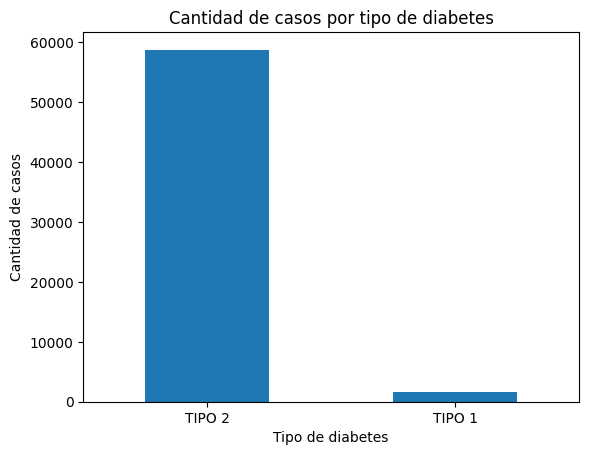

In [26]:
import matplotlib.pyplot as plt
#Se observa que la diabetes tipo 2 concentra la mayor cantidad de registros del conjunto de datos, evidenciando que constituye el principal tipo de diabetes atendido por las instituciones de salud.
# Gráfico de barras
# Normalizar valores de TIPO_DIABETES
df_diabetes['TIPO_DIABETES'] = (
    df_diabetes['TIPO_DIABETES']
    .str.strip()  
    .str.upper()   
)


df_diabetes['TIPO_DIABETES'].value_counts().plot(kind='bar')

plt.title("Cantidad de casos por tipo de diabetes")
plt.xlabel("Tipo de diabetes")
plt.ylabel("Cantidad de casos")
plt.xticks(rotation=0)
plt.show()


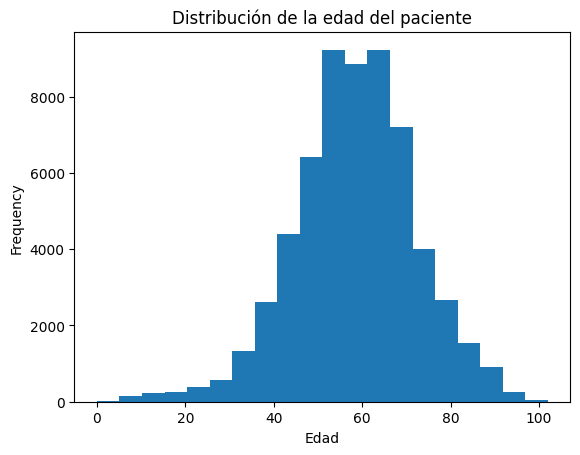

In [27]:
#La distribución de edades permite identificar el rango etario con mayor frecuencia de casos de diabetes.
df_diabetes['EDAD_PACIENTE'].plot(kind='hist', bins=20)
plt.title("Distribución de la edad del paciente")
plt.xlabel("Edad")
plt.show()

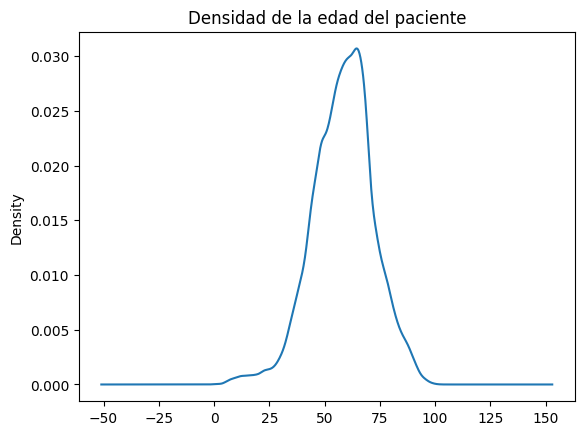

In [28]:
#La curva de densidad permite visualizar la concentración de pacientes según su edad y detectar posibles sesgos en la distribución.
df_diabetes['EDAD_PACIENTE'].plot(kind='density')
plt.title("Densidad de la edad del paciente")
plt.show()

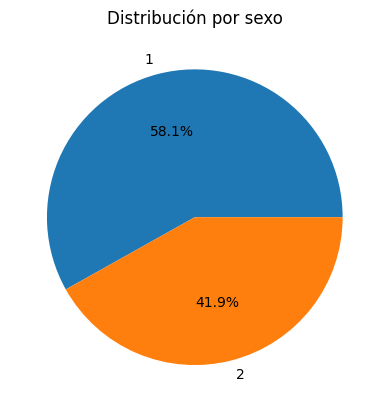

In [29]:
#El gráfico muestra la proporción de pacientes masculinos y femeninos registrados en el dataset.
df_diabetes['SEXO_PACIENTE'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Distribución por sexo")
plt.show()

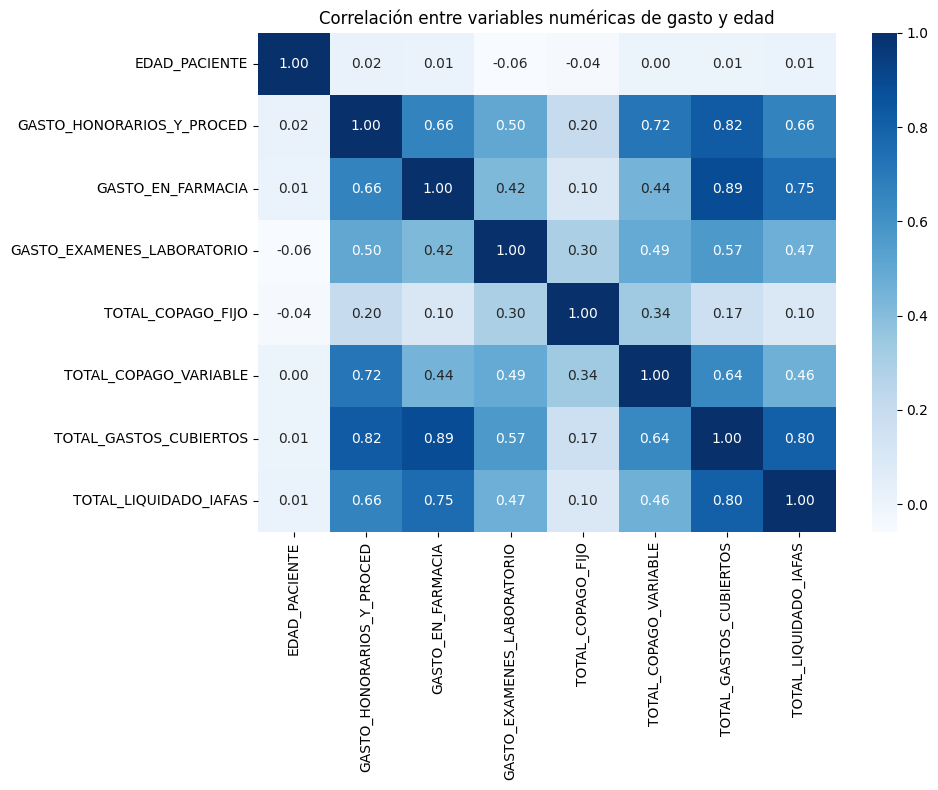

In [30]:
#El mapa de calor permite identificar el grado de relación entre las variables numéricas utilizadas en el análisis.
import seaborn as sns

cols_numericas = [
    'EDAD_PACIENTE',
    'GASTO_HONORARIOS_Y_PROCED',
    'GASTO_EN_FARMACIA',
    'GASTO_EXAMENES_LABORATORIO',
    'TOTAL_COPAGO_FIJO',
    'TOTAL_COPAGO_VARIABLE',
    'TOTAL_GASTOS_CUBIERTOS',
    'TOTAL_LIQUIDADO_IAFAS'  
]

for col in cols_numericas:
    df_diabetes[col] = pd.to_numeric(df_diabetes[col], errors='coerce')

plt.figure(figsize=(10,8))
sns.heatmap(df_diabetes[cols_numericas].corr(),
            annot=True,
            cmap='Blues',
            fmt='.2f')
plt.title("Correlación entre variables numéricas de gasto y edad")
plt.tight_layout()
plt.show()

In [32]:
#Eliminar los valores ausentes y nulos  
#df_diabetes = df_diabetes.dropna()

In [31]:
print(f"Filas antes: 70000")
print(f"Filas después: {len(df_diabetes)}")

Filas antes: 70000
Filas después: 60324


In [32]:
print(df_diabetes.isnull().sum())

CODIGO_IAFAS_CRIPTO                                     0
CODIGO_IPRESS_CRIPTO                                    0
TIPO_DOC_PAGO                                           0
NUMERO_DOC_PAGO_CRIPTO                                  0
CORRELATIVO_ATENCION                                    0
TIPO_AFILIACION_DEL_PACIENTE                            0
TIPO_DOC_IDENTIDAD                                      0
NUMERO_DOC_IDENTIDAD_CRIPTO                             0
TIPO_COBERTURA                                          3
SUBTIPO_COBERTURA                                       0
PRIMER_DIAGNOSTICO                                      0
TIPO_DIABETES                                           0
FECHA_PRESTACION                                        0
TIPO_PROFESIONAL                                        0
FECHA_NACIMIENTO_PACIENTE                               0
SEXO_PACIENTE                                           0
FILIACION_PACIENTE                                      0
UBIGEO_IPRESS 

In [33]:
df_diabetes_consolidado[[ 'UBIGEO_IPRESS',
    'CODIGO_IPRESS_CRIPTO',
    'PRIMER_DIAGNOSTICO',
    'FECHA_PRESTACION',
    'NUMERO_DOC_IDENTIDAD_CRIPTO',
    'FECHA_NACIMIENTO_PACIENTE',
    'SEXO_PACIENTE',
    'UBIGEO_AFILIADO',
    'TOTAL_LIQUIDADO_IAFAS',
    'GASTO_EXAMENES_DE_IMAGENES',
    'TIPO_AFILIACION_DEL_PACIENTE',
    'GASTO_EN_FARMACIA',
    'TOTAL_COPAGO_FIJO',
    'TOTAL_GASTOS_CUBIERTOS',
    'GASTO_EXAMENES_LABORATORIO']].describe()

,UBIGEO_IPRESS,FECHA_PRESTACION,FECHA_NACIMIENTO_PACIENTE,SEXO_PACIENTE,UBIGEO_AFILIADO,TOTAL_LIQUIDADO_IAFAS,GASTO_EXAMENES_DE_IMAGENES,GASTO_EN_FARMACIA,TOTAL_COPAGO_FIJO,TOTAL_GASTOS_CUBIERTOS,GASTO_EXAMENES_LABORATORIO
count,2447374.0,2451565,2451565,2.451565e+06,2319926.0,2.451565e+06,2.451565e+06,2.451565e+06,2.451565e+06,2.451565e+06,2.451565e+06
mean,137973.346214,2025-08-27 04:42:08.664588544,1986-03-17 04:51:18.134987200,1.568735e+00,136356.458809,4.548610e+02,5.990390e+01,1.930818e+02,2.429484e+01,4.897869e+02,3.691070e+01
min,20101.0,2008-02-28 00:00:00,1900-01-01 00:00:00,1.000000e+00,10000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,150108.0,2025-07-22 00:00:00,1971-03-28 00:00:00,1.000000e+00,140104.0,8.236000e+01,0.000000e+00,0.000000e+00,0.000000e+00,7.738000e+01,0.000000e+00
50%,150130.0,2025-08-27 00:00:00,1985-09-20 00:00:00,2.000000e+00,140124.0,1.821700e+02,0.000000e+00,8.940000e+00,0.000000e+00,1.832100e+02,0.000000e+00
75%,150135.0,2025-10-14 00:00:00,2000-04-19 00:00:00,2.000000e+00,140136.0,3.121900e+02,0.000000e+00,1.339400e+02,3.814000e+01,3.744100e+02,0.000000e+00
max,250101.0,2026-01-29 00:00:00,2026-09-01 00:00:00,2.000000e+00,950201.0,3.422000e+05,1.101700e+05,3.402036e+05,6.406039e+04,3.402036e+05,6.488447e+04
std,36785.158742,NaN,NaN,4.952530e-01,53122.44176,2.464392e+03,2.496854e+02,1.503882e+03,8.988028e+01,2.450296e+03,2.367466e+02


In [34]:
columnas_interes = [
    'UBIGEO_IPRESS',
    'CODIGO_IPRESS_CRIPTO',
    'PRIMER_DIAGNOSTICO',
    'FECHA_PRESTACION',
    'NUMERO_DOC_IDENTIDAD_CRIPTO',
    'FECHA_NACIMIENTO_PACIENTE',
    'SEXO_PACIENTE',
    'UBIGEO_AFILIADO',
    'TOTAL_LIQUIDADO_IAFAS',
    'GASTO_EXAMENES_DE_IMAGENES',
    'TIPO_AFILIACION_DEL_PACIENTE',
    'GASTO_EN_FARMACIA',
    'TOTAL_COPAGO_FIJO',
    'TOTAL_GASTOS_CUBIERTOS',
    'GASTO_EXAMENES_LABORATORIO'
]

df_interes = df_diabetes[columnas_interes]
(df_interes.shape)
(df_interes.head())

,UBIGEO_IPRESS,CODIGO_IPRESS_CRIPTO,PRIMER_DIAGNOSTICO,FECHA_PRESTACION,NUMERO_DOC_IDENTIDAD_CRIPTO,FECHA_NACIMIENTO_PACIENTE,SEXO_PACIENTE,UBIGEO_AFILIADO,TOTAL_LIQUIDADO_IAFAS,GASTO_EXAMENES_DE_IMAGENES,TIPO_AFILIACION_DEL_PACIENTE,GASTO_EN_FARMACIA,TOTAL_COPAGO_FIJO,TOTAL_GASTOS_CUBIERTOS,GASTO_EXAMENES_LABORATORIO
11,150113,9144CC7E1B4608B4FC4FA31AA392DFAA5E0B5397,E11.8,2025-09-27,6B40353F62D25C6524DABA66622F0EA8F4BFF170,1949-11-16,2,140106,604.08,0.0,REGULAR,543.58,30.25,604.08,0.00
26,150122,842179BE8942CB524E09070812A4121ED27DDF1A,E11.9,2025-10-30,5A884E351351BA3C7EF736E494B83B8BF042B726,1957-08-09,2,240102,103.80,0.0,REGULAR,0.00,0.00,103.80,0.00
47,150141,508E9DEDD8800D531EEA055C45B12CE9D3C0F444,E11.9,2025-10-22,CF65BE771B95C9156137B14A2E3F0B05F2953EB2,1983-11-11,2,140110,568.04,0.0,REGULAR,0.00,0.00,873.90,0.00
83,150130,ADECE6AAAFE7E05BF751A5A446C440980D9B1AC2,E11.9,2025-10-22,779FBB15AE45C9F02E5138C89D90F3FDA157A1EE,1968-04-06,2,140140,1058.56,0.0,REGULAR,1245.36,0.00,1245.36,0.00
196,130101,40BA7B9DF53DC1EB6A4D06DE796576706A74BAD7,E11.8,2025-11-14,9D471FB0D796819957172238BB3F65B0D5A53608,1973-01-25,1,140140,1315.36,0.0,REGULAR,1356.29,38.14,1581.75,165.46


In [35]:
# Calcular percentiles 1 y 99
p1 = df_interes['GASTO_EXAMENES_DE_IMAGENES'].quantile(0.01)
p99 = df_interes['GASTO_EXAMENES_DE_IMAGENES'].quantile(0.99)

# Identificar outliers
outliers = df_interes[
    (df_interes['GASTO_EXAMENES_DE_IMAGENES'] < p1) |
    (df_interes['GASTO_EXAMENES_DE_IMAGENES'] > p99)
]

# Cantidad y porcentaje de outliers
num_outliers = len(outliers)
porcentaje_outliers = (num_outliers / len(df_interes)) * 100

print(f"Columna        : GASTO_EXAMENES_DE_IMAGENES")
print(f"Percentil 1    : {p1:.2f}")
print(f"Percentil 99   : {p99:.2f}")
print(f"Total outliers : {num_outliers} ({porcentaje_outliers:.2f}%)")

Columna        : GASTO_EXAMENES_DE_IMAGENES
Percentil 1    : 0.00
Percentil 99   : 220.50
Total outliers : 583 (0.97%)


Columna        : GASTO_EN_FARMACIA
Límite inferior: -167.55 | Límite superior: 279.26
Total outliers : 7827 (12.97%)


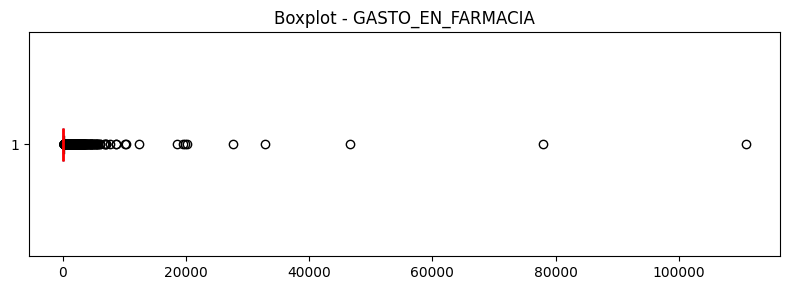

In [36]:
import matplotlib.pyplot as plt
def analizar_outliers(col):
    if df_interes[col].dtype == 'object':
        print(f"⚠️ '{col}' es texto — no aplica IQR.")
        return

    Q1 = df_interes[col].quantile(0.25)
    Q3 = df_interes[col].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = df_interes[(df_interes[col] < li) | (df_interes[col] > ls)]

    print(f"Columna        : {col}")
    print(f"Límite inferior: {li:.2f} | Límite superior: {ls:.2f}")
    print(f"Total outliers : {len(outliers)} ({len(outliers)/len(df_interes)*100:.2f}%)")

    plt.figure(figsize=(8, 3))
    plt.boxplot(df_interes[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
    plt.title(f'Boxplot - {col}')
    plt.tight_layout()
    plt.show()

analizar_outliers('GASTO_EN_FARMACIA')

In [37]:
def corregir_outliers(col):
    Q1 = df_interes[col].quantile(0.25)
    Q3 = df_interes[col].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    mediana = df_interes[col].median()
    df_interes.loc[:, col] = df_interes[col].where(
        (df_interes[col] >= li) & (df_interes[col] <= ls),
        other=mediana
    )
    print(f"✅ {col} corregido | Mediana aplicada: {mediana:.2f}")

corregir_outliers('GASTO_EN_FARMACIA')

✅ GASTO_EN_FARMACIA corregido | Mediana aplicada: 0.00


In [38]:
p1 = df_interes['TOTAL_COPAGO_FIJO'].quantile(0.01)
p99 = df_interes['TOTAL_COPAGO_FIJO'].quantile(0.99)

outliers = df_interes[
    (df_interes['TOTAL_COPAGO_FIJO'] < p1) |
    (df_interes['TOTAL_COPAGO_FIJO'] > p99)
]

print(f"Percentil 1    : {p1:.2f}")
print(f"Percentil 99   : {p99:.2f}")
print(f"Total outliers : {len(outliers)} ({len(outliers)/len(df_interes)*100:.2f}%)")

Percentil 1    : 0.00
Percentil 99   : 101.69
Total outliers : 442 (0.73%)


Columna        : TOTAL_GASTOS_CUBIERTOS
Límite inferior: -444.51 | Límite superior: 1047.57
Total outliers : 3658 (6.06%)


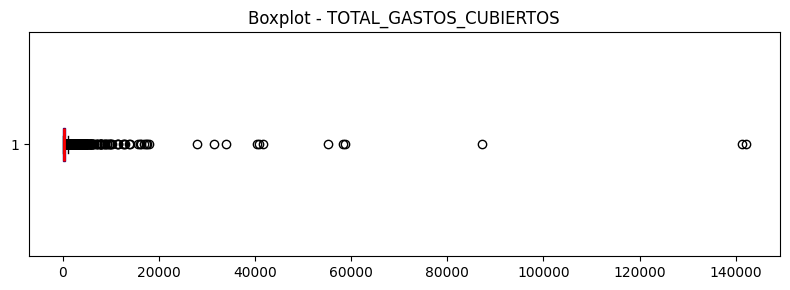

In [39]:
def analizar_outliers(col):
    if df_interes[col].dtype == 'object':
        print(f"⚠️ '{col}' es texto — no aplica IQR.")
        return

    Q1 = df_interes[col].quantile(0.25)
    Q3 = df_interes[col].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = df_interes[(df_interes[col] < li) | (df_interes[col] > ls)]

    print(f"Columna        : {col}")
    print(f"Límite inferior: {li:.2f} | Límite superior: {ls:.2f}")
    print(f"Total outliers : {len(outliers)} ({len(outliers)/len(df_interes)*100:.2f}%)")

    plt.figure(figsize=(8, 3))
    plt.boxplot(df_interes[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
    plt.title(f'Boxplot - {col}')
    plt.tight_layout()
    plt.show()

analizar_outliers('TOTAL_GASTOS_CUBIERTOS')

In [40]:
# Estadísticas descriptivas
print(df_interes['TOTAL_GASTOS_CUBIERTOS'].describe())

# 10 valores más altos
print(df_interes['TOTAL_GASTOS_CUBIERTOS'].sort_values(ascending=False).head(10))

count     60324.000000
mean        395.091516
std        1146.412613
min           0.000000
25%         115.020000
50%         267.540000
75%         488.040000
max      142101.870000
Name: TOTAL_GASTOS_CUBIERTOS, dtype: float64
1834139    142101.87
2021936    141265.23
628238      87304.27
1928036     58680.98
1375823     58388.80
1721094     55084.16
1642432     41754.62
300107      40887.83
204693      40471.34
1829408     33996.29
Name: TOTAL_GASTOS_CUBIERTOS, dtype: float64


In [41]:
p1 = df_interes['GASTO_EXAMENES_LABORATORIO'].quantile(0.01)
p99 = df_interes['GASTO_EXAMENES_LABORATORIO'].quantile(0.99)

outliers = df_interes[
    (df_interes['GASTO_EXAMENES_LABORATORIO'] < p1) |
    (df_interes['GASTO_EXAMENES_LABORATORIO'] > p99)
]

print(f"Percentil 1    : {p1:.2f}")
print(f"Percentil 99   : {p99:.2f}")
print(f"Total outliers : {len(outliers)} ({len(outliers)/len(df_interes)*100:.2f}%)")

Percentil 1    : 0.00
Percentil 99   : 620.02
Total outliers : 604 (1.00%)


In [42]:
p99 = df_interes['GASTO_EXAMENES_LABORATORIO'].quantile(0.99)

outliers = df_interes[
    df_interes['GASTO_EXAMENES_LABORATORIO'] > p99
]

# Ordenar de mayor a menor
outliers_ordenados = outliers.sort_values(
    by='GASTO_EXAMENES_LABORATORIO',
    ascending=False
)

(outliers_ordenados[['GASTO_EXAMENES_LABORATORIO',
                          'TOTAL_GASTOS_CUBIERTOS',
                          'GASTO_EN_FARMACIA',
                          'GASTO_EXAMENES_DE_IMAGENES']].head(20))

,GASTO_EXAMENES_LABORATORIO,TOTAL_GASTOS_CUBIERTOS,GASTO_EN_FARMACIA,GASTO_EXAMENES_DE_IMAGENES
1834139,13537.97,142101.87,0.00,12513.43
2021936,8098.50,141265.23,0.00,912.40
1642432,8091.49,41754.62,0.00,67.96
1829408,7330.88,33996.29,0.00,2195.57
1721094,6569.43,55084.16,0.00,1123.09
628238,5155.12,87304.27,0.00,7618.36
1873419,4734.79,17929.54,0.00,2748.22
1375823,4436.75,58388.80,0.00,1065.23
845069,4308.16,15589.05,0.00,52.85
1200994,2884.91,16979.39,0.00,2015.70


In [43]:
# MAPEAR SEXO_PACIENTE de números a texto

sexo_map = {1: 'Hombre', 2: 'Mujer'}
df_diabetes_consolidado['SEXO_PACIENTE'] = df_diabetes['SEXO_PACIENTE'].map(sexo_map)

# Verificar
print(df_diabetes['SEXO_PACIENTE'].value_counts())

SEXO_PACIENTE
1    35062
2    25262
Name: count, dtype: int64


In [44]:
import os
import pandas as pd

# Nombre del archivo
nombre_archivo = "reporte_final_diabetes.xlsx"

# Exportar a Excel
df_diabetes.to_excel(
    nombre_archivo,
    sheet_name="Diabetes",
    index=False
)

print("======================================")
print("✅ Exportación completada con éxito")
print("======================================")
print(f"Archivo: {nombre_archivo}")

# Mostrar la ubicación donde se guardó
print("\nSe guardó en:")
print(os.path.abspath(nombre_archivo))

✅ Exportación completada con éxito
Archivo: reporte_final_diabetes.xlsx

Se guardó en:
c:\Users\Usuario\Desktop\CURSOS\CURSO LUNES\DATA_DBTES\reporte_final_diabetes.xlsx
